In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Обзор данных

In [42]:
df = pd.read_csv("Iris.csv")
df = df.drop("Id", axis=1).copy()
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [43]:
print(f"Shape {df.shape}")

df.info()

df.describe()

Shape (150, 5)
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [44]:
print("NaN:\n", df.isna().sum())
print("Duplicates: ", df.duplicated().sum())

NaN:
 SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64
Duplicates:  3


In [45]:
df = df.drop_duplicates().copy()

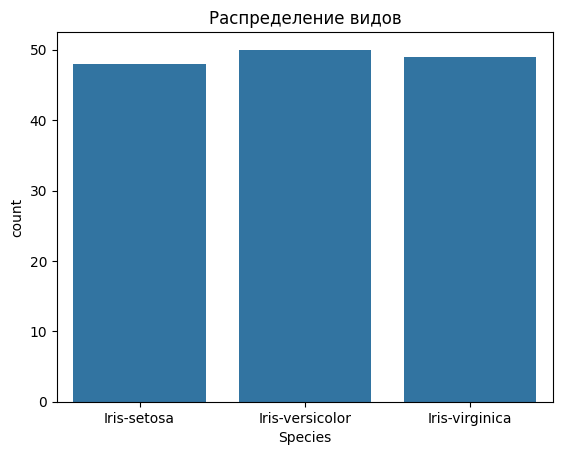

In [46]:
sns.countplot(x='Species', data = df)
plt.title("Распределение видов")
plt.show()

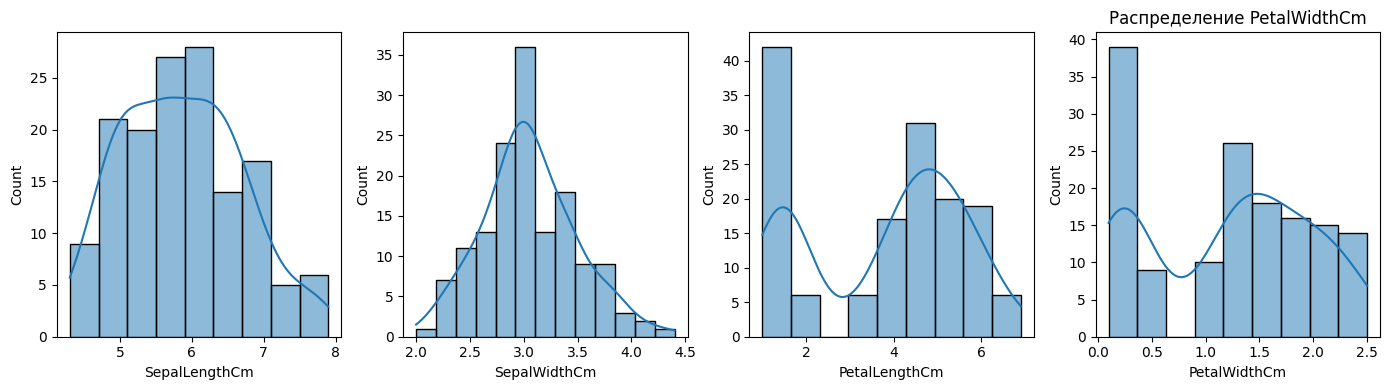

In [47]:
cols = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

fig, axes = plt.subplots(nrows=1, ncols = 4, figsize=(14,4))
axes = axes.flatten()

for i, col in enumerate(cols):

    sns.histplot(x=col, data=df, ax=axes[i], kde=True)
    plt.title(f'Распределение {col}')

plt.tight_layout()
plt.show()


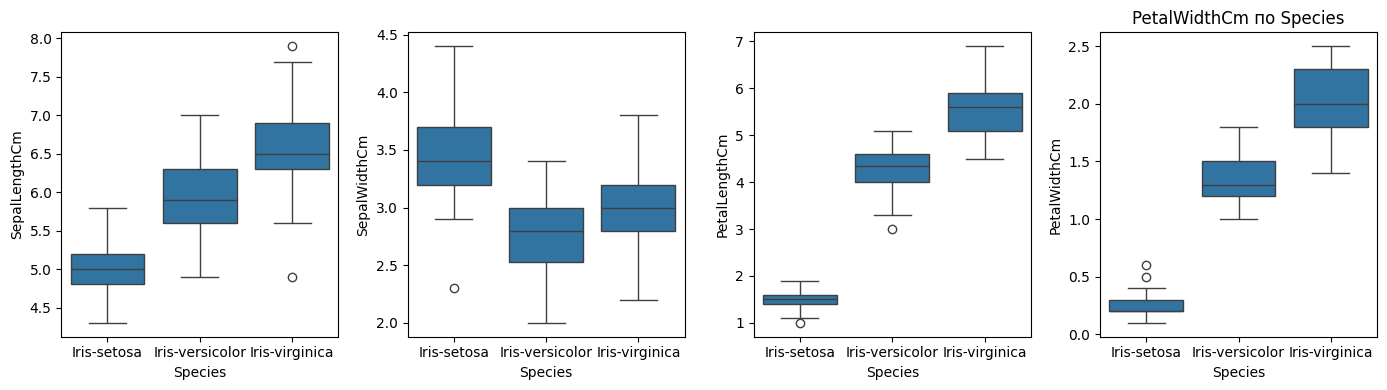

In [48]:
fig, axes = plt.subplots(figsize=(14,4), nrows=1, ncols=4)
axes = axes.flatten()

for i, col in enumerate(cols):

    sns.boxplot(ax=axes[i], x='Species', y=col, data=df)
    plt.title(f'{col} по Species')

plt.tight_layout()
plt.show()

- EDA показал, что метки распределены равномерно. Признаки пересекаются частично. Выбросов и аномалий нет

## Подготовка данных

- Для метки буду использовать label encoding. Он удобен, так как target разделен на 3 класса

In [49]:
df_model = df.copy()
df_model.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [50]:
le = LabelEncoder()

df_model['Species'] = le.fit_transform(df_model['Species'])

df_model.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [51]:
y = df_model['Species']

X = df_model[[col for col in df_model.columns if col != 'Species']]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42,
    stratify =y
)

- Масштабирование важно для KNN, потому что алгоритм считает расстояние между признаками

In [52]:
scaler = MinMaxScaler(feature_range=(0,1))

scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

## Обучение KNN

Metric euclidean | weight uniform | best accuracy 1.0 k=7
Metric euclidean | weight distance | best accuracy 1.0 k=7
Metric manhattan | weight uniform | best accuracy 0.9666666666666667 k=1
Metric manhattan | weight distance | best accuracy 0.9666666666666667 k=1
Metric minkowski | weight uniform | best accuracy 1.0 k=7
Metric minkowski | weight distance | best accuracy 1.0 k=7
Metric cosine | weight uniform | best accuracy 0.9666666666666667 k=12
Metric cosine | weight distance | best accuracy 0.9333333333333333 k=12


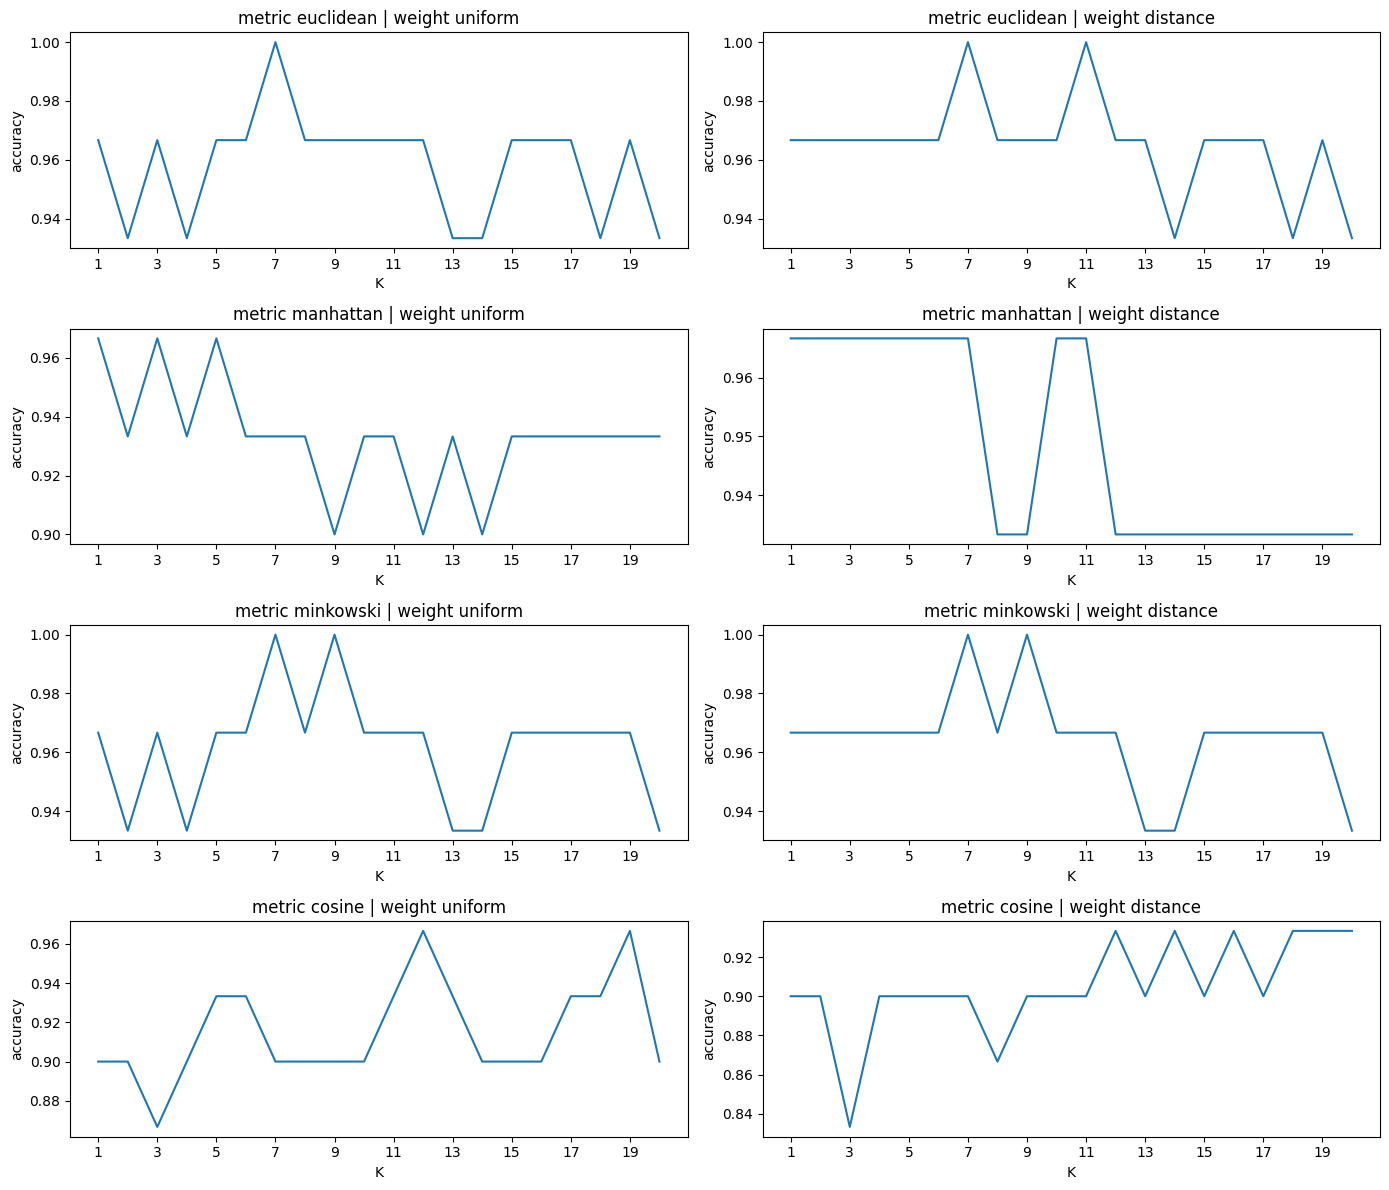

In [53]:
k_values=np.arange(1,21)
metrics = ['euclidean', 'manhattan', 'minkowski', 'cosine']
weights = ['uniform', 'distance']

fig, ax = plt.subplots(4,2, figsize = (14,12))


for i, metric in enumerate(metrics):
    for j, weight in enumerate(weights):
        res = []
        for k in k_values:
            knn = KNeighborsClassifier(
                n_neighbors=k,
                metric=metric,
                weights=weight,
                p= 3 if metric == 'minkowski' else (2 if metric == 'euclidian' else 1)
            )

            knn.fit(X_train, Y_train)
            acc = knn.score(X_test, Y_test)
            res.append(acc)
        ax[i][j].plot(k_values, res)
        ax[i][j].set_title(f"metric {metric} | weight {weight}")
        ax[i][j].set_xticks(np.arange(1,21,2))
        ax[i][j].set_xlabel('K')
        ax[i][j].set_ylabel('accuracy')
        print(f'Metric {metric} | weight {weight} | best accuracy {np.max(res)} k={k_values[np.argmax(res)]}')

plt.tight_layout()
plt.show()



## Подбор гиперпараметров

### Используем кросс-валидацию для подбора гиперпараметров

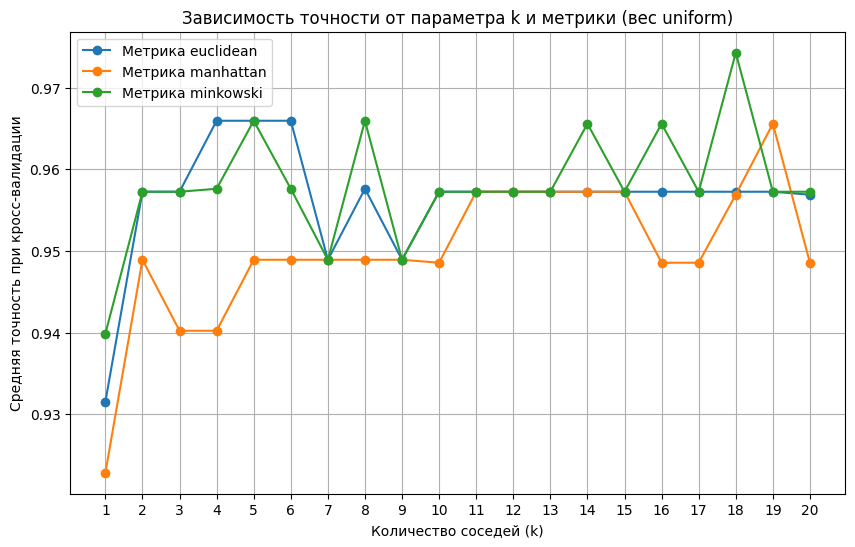

In [54]:

k_range = range(1, 21)
metrics = ['euclidean', 'manhattan', 'minkowski']
cv_scores = {}


for metric in metrics:
    cv_scores[metric] = []
    sklearn_p = 2 if metric == 'euclidean' else (3 if metric == 'minkowski' else 1)
    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric, p=sklearn_p, weights = 'uniform')
        scores = cross_val_score(knn, X_train, Y_train, cv=5, scoring='accuracy')
        cv_scores[metric].append(scores.mean())


plt.figure(figsize=(10, 6))
for metric in metrics:
    plt.plot(k_range, cv_scores[metric], marker='o', label=f'Метрика {metric}')

plt.title('Зависимость точности от параметра k и метрики (вес uniform)')
plt.xlabel('Количество соседей (k)')
plt.ylabel('Средняя точность при кросс-валидации')
plt.xticks(k_range)
plt.grid(True)
plt.legend()
plt.show()

In [55]:
for metric in metrics:
    best_k = k_range[np.argmax(cv_scores[metric])]
    best_score = max(cv_scores[metric])
    print(f"Метрика {metric}: Лучшее значение k = {best_k}, точность = {best_score:.4f}")

Метрика euclidean: Лучшее значение k = 4, точность = 0.9659
Метрика manhattan: Лучшее значение k = 19, точность = 0.9656
Метрика minkowski: Лучшее значение k = 18, точность = 0.9743


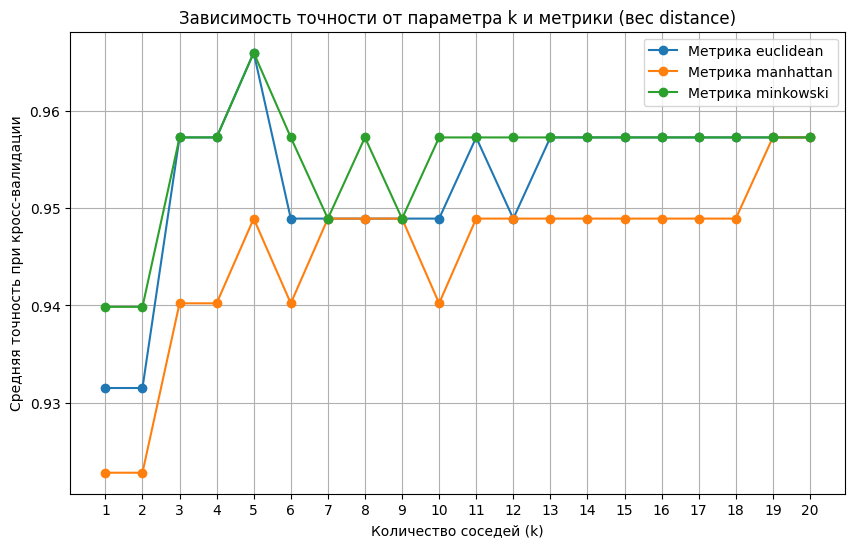

In [56]:
k_range = range(1, 21)
metrics = ['euclidean', 'manhattan', 'minkowski']
cv_scores = {}


for metric in metrics:
    cv_scores[metric] = []
    sklearn_p = 2 if metric == 'euclidean' else (3 if metric == 'minkowski' else 1)
    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric, p=sklearn_p, weights = 'distance')
        scores = cross_val_score(knn, X_train, Y_train, cv=5, scoring='accuracy')
        cv_scores[metric].append(scores.mean())


plt.figure(figsize=(10, 6))
for metric in metrics:
    plt.plot(k_range, cv_scores[metric], marker='o', label=f'Метрика {metric}')

plt.title('Зависимость точности от параметра k и метрики (вес distance)')
plt.xlabel('Количество соседей (k)')
plt.ylabel('Средняя точность при кросс-валидации')
plt.xticks(k_range)
plt.grid(True)
plt.legend()
plt.show()

In [57]:
for metric in metrics:
    best_k = k_range[np.argmax(cv_scores[metric])]
    best_score = max(cv_scores[metric])
    print(f"Метрика {metric}: Лучшее значение k = {best_k}, точность = {best_score:.4f}")

Метрика euclidean: Лучшее значение k = 5, точность = 0.9659
Метрика manhattan: Лучшее значение k = 19, точность = 0.9572
Метрика minkowski: Лучшее значение k = 5, точность = 0.9659


- Лучший результат у minkowski: Лучшее значение k = 18, точность = 0.9743

### Финальный тест

In [58]:
best_k = 18
best_metric = 'minkowski'
best_weights = 'uniform'

knn = KNeighborsClassifier(
    n_neighbors=best_k,
    metric=best_metric,
    weights=best_weights,
)

knn.fit(X_train, Y_train)

Y_pred = knn.predict(X_test)

test_accuracy = accuracy_score(Y_test, Y_pred)
print(f'Test accuracy: {test_accuracy:.4f}')

Test accuracy: 0.9333


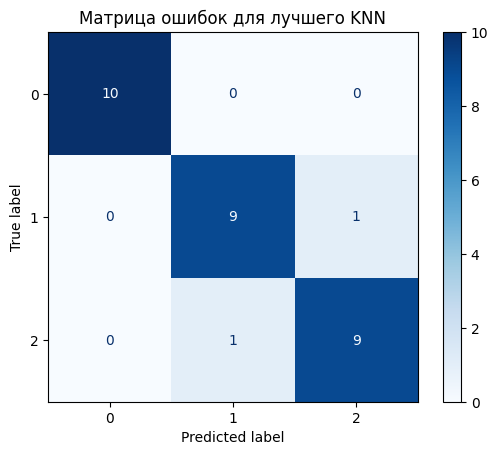

In [61]:
cm = confusion_matrix(Y_test, Y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)
disp.plot(cmap="Blues", values_format="d")
plt.title("Матрица ошибок для лучшего KNN")
plt.show()

## Вывод

- Масштабирование важно для KNN, потому что без него признаки с большими численными значениями начинают доминировать в расстоянии и «перетягивать» решение.

- лучший результат на кросс-валидации показал minkowski, k = 18, weight uniform

- Точность на тесте и оьучении разная, потому что датасет небольшой и одна конкретная тестовая выборка может заметно отличаться от средних результатов кросс‑валидации.